# 12 — LSTM Autoencoder Baseline

Non-linear reconstruction baseline. An LSTM encoder compresses each
`WINDOW_SIZE=100` window to a latent vector; an LSTM decoder reconstructs
it. Anomalous windows reconstruct worse → higher window-mean MSE.

**Inputs**: arrays from `data/processed/bootcamp/` (run `run_preprocessing_bootcamp()`)
**Outputs**: `models/lstm_ae_bootcamp.keras`

Scoring, threshold tuning and the test_intern evaluation all go through the
shared `sentinel.ml_logic` modules so this notebook is directly comparable
to NB 11 (PCA) and NB 13 (CNN-AE).

**Sections**
0. Setup & Imports
1. Load bootcamp arrays
2. Build and train LSTM-AE on `FIT_SIZE` subsampled nominal windows
3. Score val + test_intern via `score_windows`
4. Tune threshold on val via `tune_threshold`
5. Evaluate on test_intern — five-metric table
6. Bootstrap CI on test_intern event-F0.5
7. Save model artifact
8. Summary

## 0 — Setup & Imports

In [1]:
import sys, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sentinel.ml_logic.scoring    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
    LATENT_DIM, HIDDEN_DIM, DROPOUT,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

BOOTCAMP_DIR    = Path('../data/processed/bootcamp')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}   (None = fit on every nominal window)')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000   (None = fit on every nominal window)


---
## 1 — Load Bootcamp Arrays

Three-way chronological labelled split from `run_preprocessing_bootcamp()`:
70 % train / 15 % val / 15 % test_intern. Events do not straddle boundaries.

In [2]:
with open(BOOTCAMP_DIR / 'bootcamp_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(BOOTCAMP_DIR / 'X_train_nom.npy')

val_scaled  = np.load(BOOTCAMP_DIR / 'val_scaled.npy')
y_val       = np.load(BOOTCAMP_DIR / 'y_val.npy')

test_scaled = np.load(BOOTCAMP_DIR / 'test_intern_scaled.npy')
y_test      = np.load(BOOTCAMP_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 — Build and Train LSTM-AE

One LSTM per side, latent 32, hidden 64, dropout 0.2. With `FIT_SIZE=None`
we train on every nominal window; with an integer we train on a random
subsample (seeded). Each window is z-normalised per-window before the
forward pass — the model reconstructs shape, not magnitude — so drift
between train and test_intern is attenuated (documented failure mode of
NB 05 v1 on Kaggle).

In [3]:
def build_lstm_ae(window_size, n_channels,
                  latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
    inputs  = layers.Input(shape=(window_size, n_channels))
    x       = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)(inputs)
    latent  = layers.LSTM(latent_dim,  return_sequences=False, dropout=dropout)(x)
    x       = layers.RepeatVector(window_size)(latent)
    x       = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_channels))(x)
    model = Model(inputs, outputs, name='lstm_ae_bootcamp')
    model.compile(optimizer='adam', loss='mse')
    return model


def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


model = build_lstm_ae(WIN, N_FEAT)
model.summary()

Model: "lstm_ae_bootcamp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 58)        │         3,770 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,506 (283.23 KB)

 Trainable params: 72,506 (283.23 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    X_fit_raw = X_train_nom[idx]
    print(f'Training on {len(X_fit_raw):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

X_fit = zscore_window(X_fit_raw)
del X_fit_raw

EPOCHS     = 25
BATCH_SIZE = 128
MODEL_PATH = MODELS_DIR / 'lstm_ae_bootcamp.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
print(f'Trained in {train_seconds/60:.1f} min  ({len(history.history["loss"])} epochs)')
print(f'Model saved → {MODEL_PATH}')

Training on 50,000 subsampled windows (FIT_SIZE=50,000)
Epoch 1/25
352/352 - 48s - 135ms/step - loss: 0.8492 - val_loss: 0.8250 - learning_rate: 0.0010
Epoch 2/25
352/352 - 44s - 124ms/step - loss: 0.8174 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 3/25
352/352 - 40s - 114ms/step - loss: 0.8026 - val_loss: 0.7964 - learning_rate: 0.0010
Epoch 4/25
352/352 - 40s - 113ms/step - loss: 0.7996 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 5/25
352/352 - 40s - 113ms/step - loss: 0.7980 - val_loss: 0.7939 - learning_rate: 0.0010
Epoch 6/25
352/352 - 40s - 114ms/step - loss: 0.7965 - val_loss: 0.7922 - learning_rate: 0.0010
Epoch 7/25
352/352 - 40s - 115ms/step - loss: 0.7951 - val_loss: 0.7907 - learning_rate: 0.0010
Epoch 8/25
352/352 - 40s - 114ms/step - loss: 0.7939 - val_loss: 0.7895 - learning_rate: 0.0010
Epoch 9/25
352/352 - 39s - 111ms/step - loss: 0.7928 - val_loss: 0.7885 - learning_rate: 0.0010
Epoch 10/25
352/352 - 39s - 110ms/step - loss: 0.7920 - val_loss: 0.7883 - learn

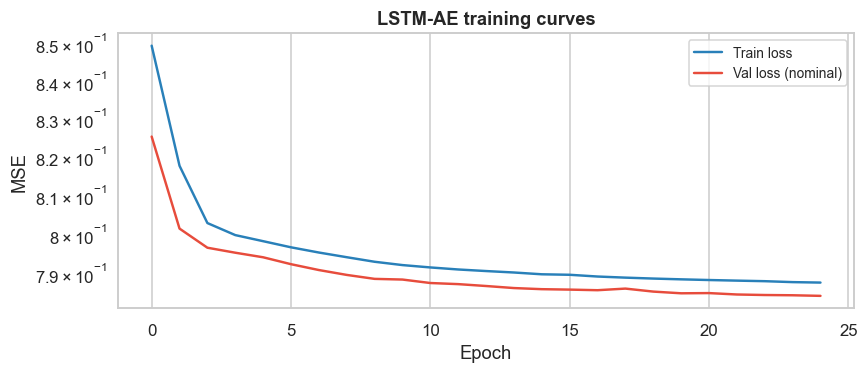

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('LSTM-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 — Score Val + test_intern

Important: `score_windows` passes each row-slice window through
`model.predict(X_3d)`. The model expects z-normalised input, so we wrap it in
a tiny adaptor class that handles z-normalisation inside `.predict`. This
keeps the scoring API uniform across PCA / LSTM-AE / CNN-AE.

In [6]:
class ZNormAdapter:
    '''Wraps a Keras AE trained on z-normalised windows so score_windows can
    treat it like any reconstruction model.

    score_windows computes the per-window MSE as ((X - predict(X))**2).mean.
    We want the z-space residual (Xn - Xhat), so we return a tensor `pred`
    satisfying (X - pred) == (Xn - Xhat). Solving: pred = X - Xn + Xhat.'''
    def __init__(self, model):
        self.model = model

    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat


scorer = ZNormAdapter(model)

t0 = time.time()
val_scores = score_windows(scorer, val_scaled, win=WIN, batch=256)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(scorer, test_scaled, win=WIN, batch=256)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (5.5s)   range [0.6878, 0.9665]
test_scores: (2186220,)   (3.9s)   range [0.7053, 0.9875]


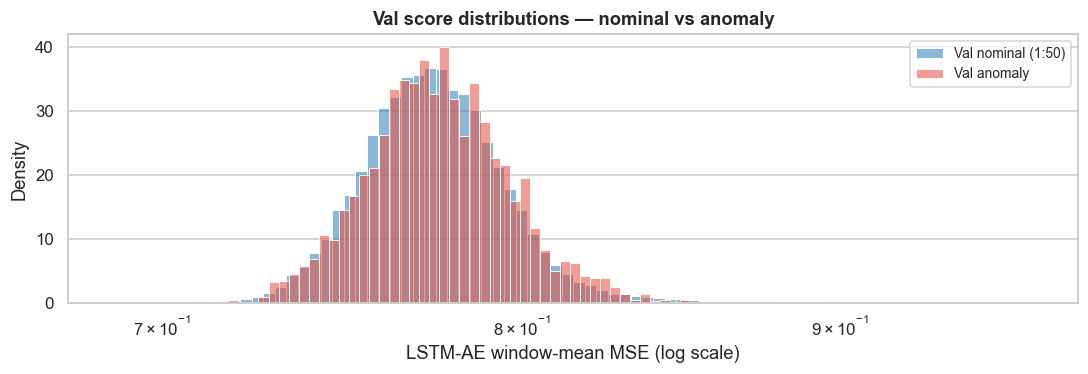

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('LSTM-AE window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions — nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 — Tune Threshold on Val (event-wise F0.5)

In [8]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 0.829141   Val event-F0.5: 0.0565


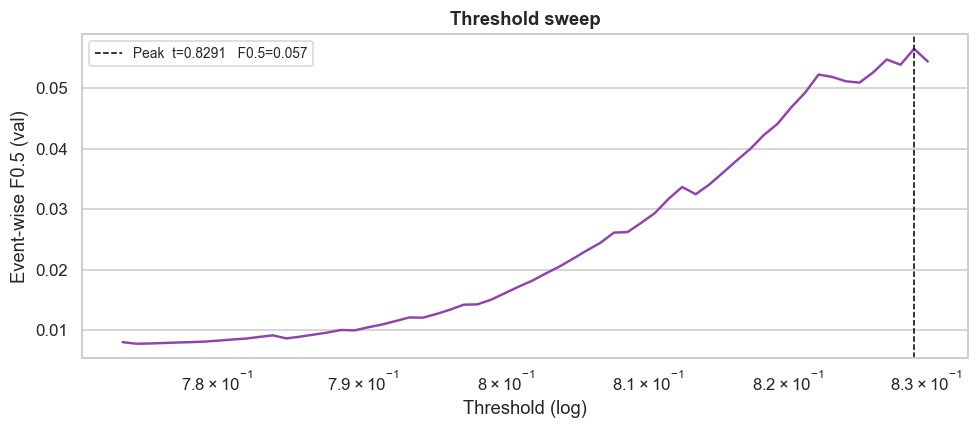

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#8e44ad')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 — Evaluate on test_intern — Five-Metric Table

Same five metrics as NB 11 / NB 13: Event F0.5, Event recall, Event
precision, ESA corrected F0.5, Row F1. Nothing else.

In [10]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.0733
      Event recall 0.6296
   Event precision 0.0601
ESA corrected F0.5 0.0721
            Row F1 0.0343


---
## 6 — Bootstrap CI on test_intern Event-F0.5

In [11]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (611.7s)
  mean     : 0.0475
  std      : 0.0069
  95 % CI  : [0.0347, 0.0606]


---
## 7 — Save Model Artifact

No submission is written — the 1x notebooks evaluate locally against
test_intern only.

In [12]:
print(f'Model saved → {MODEL_PATH} (written during fit by ModelCheckpoint)')

Model saved → ../models/lstm_ae_bootcamp.keras (written during fit by ModelCheckpoint)


---
## 8 — Summary

| Item | Value |
|---|---|
| Fit size | `FIT_SIZE` from `sentinel.params` (see §2 print) |
| Architecture | LSTM(64) → LSTM(32) → RepeatVector → LSTM(64) → Dense |
| Training | z-normalised windows, Adam, EarlyStopping |
| Val event-F0.5 | see §4 |
| **test_intern event-F0.5** | see §5 |
| 95 % bootstrap CI | see §6 |

### Why per-window z-normalisation
Without it, the model reconstructs absolute magnitudes and the scale drift
between train and test_intern dominates the reconstruction error. With z-norm,
the model reconstructs *shape* — drift-robust but less sensitive to pure
magnitude anomalies. NB 05 v1 on Kaggle lost to PCA (0.078 vs 0.599 private)
because of exactly this failure mode.

### What to try next
- Top-k channel MSE at scoring (mean over the 5 largest per-channel errors
  rather than all 58). NB 05 v2 used this; the bootcamp scoring API doesn't
  yet support it — would require a `reduce=` kwarg on `score_windows`.
- Overlapping scoring windows (stride < WINDOW_SIZE).
- Ensemble with NB 11 (PCA) via rank fusion.

## Results Summary

**Setup**
- Model: LSTM-AE (encoder LSTM 64 → LSTM 32, decoder LSTM 64 → TimeDistributed Dense 58), 72,506 params
- Fit: 50,000 subsampled nominal windows, 25 epochs, **16.5 min on GPU**
- Final train loss 0.7876 / val loss 0.7842 (still slowly improving — early-stop never triggered)
- Per-window z-normalisation; `ZNormAdapter` so `score_windows` sees the z-space residual

**Threshold tuning (val)**
- Best threshold: `0.829141`
- Val event-F0.5 at best threshold: **0.0565**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.0733** |
| Event recall | 0.6296 |
| Event precision | 0.0601 |
| ESA corrected F0.5 | 0.0721 |
| Row F1 | 0.0343 |

**Bootstrap (event-block, aligned truth/pred)**
- Mean event-F0.5: 0.0475 · std 0.0069 · 95 % CI **[0.0347, 0.0606]**
- Wall time: 611.7 s

**Verdict**
- The model reconstructs nominal *and* anomalous windows almost equally well (val score range only `[0.69, 0.97]`), so the residual distribution barely separates classes.
- Recall is decent (0.63 — it does flag ~17 of 27 events) but precision collapses to 6 % because the per-row alarm density on nominals is enormous.
- Significantly worse than the PCA baseline. Likely fixes: more capacity (deeper / wider), longer training, per-channel normalisation, or scoring on contiguous overlapping windows instead of `score_windows` non-overlapping reshape.
